In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/drive/MyDrive/industrial-ai-project/data/processed/metropt3_features.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

split_date = pd.to_datetime("2020-06-08 00:00:00")
train_df = df[df['timestamp'] < split_date]
test_df = df[df['timestamp'] >= split_date]

feature_cols = [
    'TP2_rolling_mean', 'TP2_rolling_max', 'TP2_rolling_std',
    'H1_rolling_mean', 'H1_rolling_max', 'H1_rolling_std',
    'Oil_temperature_rolling_mean', 'Oil_temperature_rolling_max', 'Oil_temperature_rolling_std',
    'Motor_current_rolling_mean', 'Motor_current_rolling_max', 'Motor_current_rolling_std'
]

X_train = train_df[feature_cols]
y_train = train_df['is_failure']
X_test = test_df[feature_cols]
y_test = test_df['is_failure']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model ready:", model.score(X_test_scaled, y_test))

Model ready: 0.9983288340403651


In [ ]:
!pip install shap -q

In [ ]:
import shap

# Create a SHAP explainer for our Logistic Regression model
explainer = shap.LinearExplainer(model, X_train_scaled)

# Calculate SHAP values for the test set (this explains each prediction)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (101127, 12)


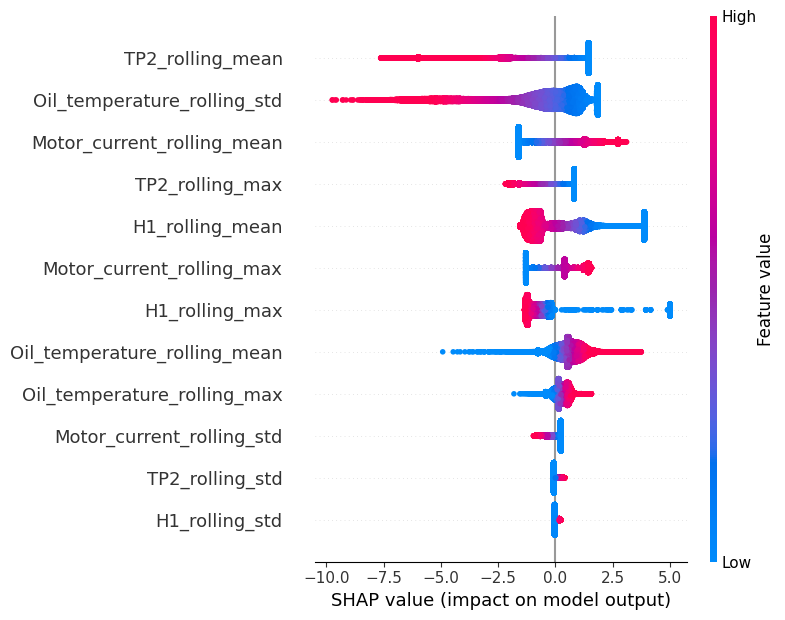

In [ ]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

## SHAP Feature Importance Results

Top predictors (in order of importance):
1. TP2_rolling_mean — lower values increase failure risk (consistent
   with EDA: pressure fails to reach normal peak during failure)
2. Oil_temperature_rolling_std
3. Motor_current_rolling_mean
4. TP2_rolling_max
5. H1_rolling_mean

These results independently confirm the patterns discovered in EDA —
the model learned the same physical signatures (pressure drop,
temperature instability) that we identified visually, without being
told about them explicitly.

Timestamp: 2020-07-15 15:20:00
Actual label: 1


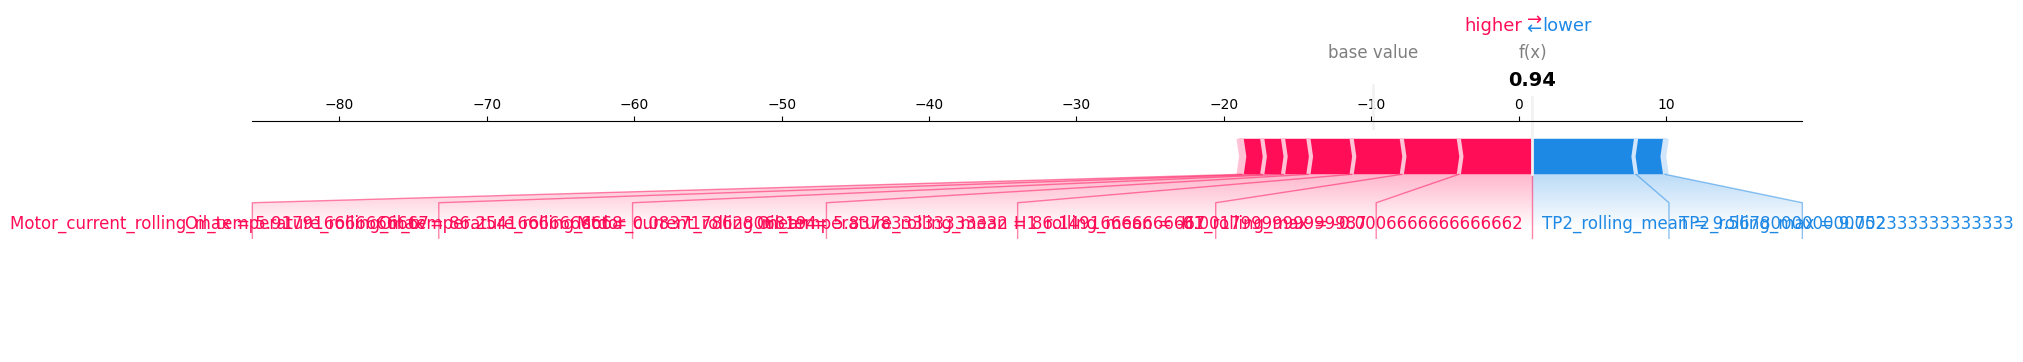

In [ ]:
# Find a row that's an actual failure, from the known Failure #4 period
failure_row_index = test_df[test_df['is_failure'] == 1].index[50]  # pick one example
row_position = test_df.index.get_loc(failure_row_index)

print("Timestamp:", test_df.loc[failure_row_index, 'timestamp'])
print("Actual label:", test_df.loc[failure_row_index, 'is_failure'])

# Show force plot for this specific row
shap.force_plot(
    explainer.expected_value,
    shap_values[row_position],
    X_test.iloc[row_position],
    feature_names=feature_cols,
    matplotlib=True
)